In [25]:
import pandas as pd
import numpy as np
import geopandas as gpd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings

In [26]:
migrations_flows = pd.read_csv('/Users/user1/Documents/housing_zones/migration_flow_la_2023.csv')
commuting_flows = pd.read_csv('/Users/user1/Documents/housing_zones/commuting_flow_la_2023.csv')

In [27]:
la_2023_shape_file = '/Users/user1/Downloads/Local_Authority_Districts_May_2023_UK_BFE_V2_5074811840009224353'

In [28]:
gdf_la_2023 = gpd.read_file(la_2023_shape_file)

In [29]:
#Only keep LAD23CD in Beginning with E and W
gdf_la_2023 = gdf_la_2023[gdf_la_2023['LAD23CD'].str.startswith(('E', 'W'))]

# Combined Commuting + Migration Method

## From "Geography of Housing Areas" Paper

This implements the **two-step, non-hierarchical approach** that combines commuting and migration flows:

### Step 1: Build Commuting-Based Areas (72.5% closure)
- Group LAs based on commuting flows until 72.5% self-containment reached

### Step 2: Test Migration & Re-group (55% closure)  
- Test each commuting area for 55% migration closure
- **Crucially**: Areas that fail are **broken down** to constituent LAs
- Failed LAs are **re-grouped** using migration flows
- Final geography meets **BOTH** thresholds

### Expected Results
- Paper produced **93 HMAs** for England (vs 85 from commuting-only)
- More separation in urban areas (e.g., Sunderland from Newcastle)
- Better performance on technocratic criteria

In [30]:
# Inspect the data structure
print("Migration flows shape:", migrations_flows.shape)
print("Migration flows columns:", list(migrations_flows.columns))
print("\nCommuting flows shape:", commuting_flows.shape)
print("Commuting flows columns:", list(commuting_flows.columns))
print("\nGeoDataFrame shape:", gdf_la_2023.shape)
print("GeoDataFrame columns:", list(gdf_la_2023.columns[:10]))

Migration flows shape: (84762, 3)
Migration flows columns: ['outla', 'inla', 'moves']

Commuting flows shape: (80932, 3)
Commuting flows columns: ['RES_LAD23CD', 'WORK_LAD23CD', 'flow']

GeoDataFrame shape: (318, 9)
GeoDataFrame columns: ['LAD23CD', 'LAD23NM', 'LAD23NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']


In [32]:
# Add internal flows (staying in same LA) - these are often missing from flow data
# Calculate total population from outflows to estimate internal retention

# For commuting
commuting_outflows = commuting_flows_clean.groupby('origin')['flow'].sum()
# Estimate internal flows assuming similar self-containment patterns
commuting_internal = pd.DataFrame({
    'origin': commuting_outflows.index,
    'destination': commuting_outflows.index,
    'flow': commuting_outflows.values * 0.75  # Assume ~75% work locally on average
})

commuting_with_internal = pd.concat([commuting_flows_clean, commuting_internal], ignore_index=True)

# For migration
migration_outflows = migrations_flows_clean.groupby('origin')['flow'].sum()
migration_internal = pd.DataFrame({
    'origin': migration_outflows.index,
    'destination': migration_outflows.index,
    'flow': migration_outflows.values * 0.85  # Assume ~85% don't migrate
})

migration_with_internal = pd.concat([migrations_flows_clean, migration_internal], ignore_index=True)

print("✓ Added internal flows")
print(f"  Commuting: {len(commuting_flows_clean):,} → {len(commuting_with_internal):,} flows")
print(f"  Migration: {len(migrations_flows_clean):,} → {len(migration_with_internal):,} flows")

✓ Added internal flows
  Commuting: 80,932 → 81,250 flows
  Migration: 84,762 → 85,080 flows


In [33]:
# Create flow matrices for easier lookup
def create_flow_dict(flow_df):
    """Convert flow DataFrame to nested dict: {origin: {destination: flow}}"""
    flow_dict = {}
    for _, row in flow_df.iterrows():
        origin = row['origin']
        dest = row['destination']
        flow = row['flow']
        
        if origin not in flow_dict:
            flow_dict[origin] = {}
        flow_dict[origin][dest] = flow
    
    return flow_dict

commuting_flows_la = create_flow_dict(commuting_with_internal)
migration_flows_la = create_flow_dict(migration_with_internal)

print("✓ Created flow lookup dictionaries")
print(f"  Commuting: {len(commuting_flows_la)} origin LAs")
print(f"  Migration: {len(migration_flows_la)} origin LAs")

✓ Created flow lookup dictionaries
  Commuting: 318 origin LAs
  Migration: 318 origin LAs


In [34]:
# Build neighborhood graph - find which LAs are adjacent
from shapely.geometry import Point

def build_neighbors_dict(gdf):
    """Find neighboring LAs based on shared boundaries"""
    neighbors = {}
    
    for idx1, row1 in gdf.iterrows():
        la1 = row1['LAD23CD']
        neighbors[la1] = set()
        
        for idx2, row2 in gdf.iterrows():
            if idx1 != idx2:
                la2 = row2['LAD23CD']
                # Check if geometries touch or intersect
                if row1.geometry.touches(row2.geometry) or row1.geometry.intersects(row2.geometry):
                    neighbors[la1].add(la2)
    
    return neighbors

print("Building neighborhood graph...")
neighbors = build_neighbors_dict(gdf_la_2023)
print(f"✓ Built neighbors dictionary for {len(neighbors)} LAs")

Building neighborhood graph...
✓ Built neighbors dictionary for 318 LAs


In [35]:
# Core algorithm functions

def self_containment(region_las, flows_dict):
    """Calculate self-containment for a set of LAs"""
    internal_flow = 0
    total_flow = 0
    
    for origin in region_las:
        if origin not in flows_dict:
            continue
        for dest, flow in flows_dict[origin].items():
            total_flow += flow
            if dest in region_las:
                internal_flow += flow
    
    if total_flow == 0:
        return 0
    return internal_flow / total_flow

def bidirectional_flows(region_a, region_b, flows_dict):
    """Calculate sum of flows in both directions between two regions"""
    flow = 0
    
    # Flows from A to B
    for origin in region_a:
        if origin not in flows_dict:
            continue
        for dest in region_b:
            if dest in flows_dict[origin]:
                flow += flows_dict[origin][dest]
    
    # Flows from B to A
    for origin in region_b:
        if origin not in flows_dict:
            continue
        for dest in region_a:
            if dest in flows_dict[origin]:
                flow += flows_dict[origin][dest]
    
    return flow

print("✓ Defined helper functions")

✓ Defined helper functions


## STEP 1: Build Commuting-Based Areas (72.5% Threshold)

In [ ]:
COMMUTING_THRESHOLD = 0.725  # 72.5% from paper
MIGRATION_THRESHOLD = 0.55   # 55% from paper

print("=" * 80)
print("STEP 1: Building commuting-based areas")
print(f"Target: {COMMUTING_THRESHOLD:.1%} commuting closure")
print("=" * 80)

# Initialise - each LA starts as its own region
commuting_regions = {la: {la} for la in gdf_la_2023['LAD23CD']}
sc_cache_commuting = {la: self_containment({la}, commuting_flows_la) 
                      for la in commuting_regions.keys()}

iteration = 0
max_iterations = 2000

while iteration < max_iterations:
    iteration += 1
    
    # Find regions below threshold
    failing_regions = [region_id for region_id, sc in sc_cache_commuting.items() 
                      if sc < COMMUTING_THRESHOLD]
    
    if not failing_regions:
        print(f"\n✓ All regions meet {COMMUTING_THRESHOLD:.1%} threshold after {iteration-1} iterations")
        break
    
    if iteration % 10 == 0:
        print(f"Iteration {iteration}: {len(commuting_regions)} regions, {len(failing_regions)} below threshold")
    
    # Find best pair to merge
    best_pair_id = None
    best_flow = 0
    
    for region_id in failing_regions:
        r = commuting_regions[region_id]
        
        # Get neighboring LAs
        r_neighbors = set()
        for la in r:
            if la in neighbors:
                r_neighbors.update(neighbors[la])
        r_neighbors = r_neighbors - r
        
        # Find which regions these neighbors belong to
        for other_id, s in commuting_regions.items():
            if other_id == region_id:
                continue
            if not r_neighbors.intersection(s):
                continue
            
            # Calculate bidirectional commuting flow
            flow = bidirectional_flows(r, s, commuting_flows_la)
            if flow > best_flow:
                best_flow = flow
                best_pair_id = (region_id, other_id)
    
    if best_pair_id is None:
        print(f"\n⚠ No valid merges found. Stopping with {len(failing_regions)} regions below threshold")
        break
    
    # Merge the best pair
    i, j = best_pair_id
    merged = commuting_regions[i] | commuting_regions[j]
    
    del commuting_regions[i]
    del commuting_regions[j]
    del sc_cache_commuting[i]
    del sc_cache_commuting[j]
    
    new_id = f"R_{iteration}"
    commuting_regions[new_id] = merged
    sc_cache_commuting[new_id] = self_containment(merged, commuting_flows_la)

print(f"\n✓ Created {len(commuting_regions)} commuting-based regions")

STEP 1: Building commuting-based areas
Target: 72.5% commuting closure
Iteration 10: 309 regions, 272 below threshold
Iteration 20: 299 regions, 261 below threshold
Iteration 30: 289 regions, 250 below threshold
Iteration 40: 279 regions, 239 below threshold
Iteration 50: 269 regions, 228 below threshold
Iteration 60: 259 regions, 218 below threshold
Iteration 70: 249 regions, 208 below threshold
Iteration 80: 239 regions, 198 below threshold
Iteration 90: 229 regions, 186 below threshold
Iteration 100: 219 regions, 176 below threshold
Iteration 110: 209 regions, 166 below threshold
Iteration 120: 199 regions, 155 below threshold
Iteration 130: 189 regions, 144 below threshold
Iteration 140: 179 regions, 132 below threshold
Iteration 150: 169 regions, 122 below threshold
Iteration 160: 159 regions, 112 below threshold
Iteration 170: 149 regions, 101 below threshold
Iteration 180: 139 regions, 91 below threshold
Iteration 190: 129 regions, 79 below threshold
Iteration 200: 119 regions, 

## STEP 2: Test Migration Closure & Identify Failed Regions

In [37]:
print("=" * 80)
print(f"STEP 2: Testing migration closure ({MIGRATION_THRESHOLD:.1%} threshold)")
print("=" * 80)

passed_regions = {}  # Regions that meet both thresholds
failed_las = set()   # LAs from regions that failed migration test

for region_id, region_las in commuting_regions.items():
    # Test migration closure
    migration_sc = self_containment(region_las, migration_flows_la)
    commuting_sc = sc_cache_commuting[region_id]
    
    if migration_sc >= MIGRATION_THRESHOLD:
        # Region passes both tests - keep it
        passed_regions[region_id] = region_las
        print(f"  ✓ Region {region_id}: {commuting_sc:.1%} commuting, {migration_sc:.1%} migration ({len(region_las)} LAs)")
    else:
        # Region fails migration test - dissolve it
        failed_las.update(region_las)
        print(f"  ✗ Region {region_id}: {commuting_sc:.1%} commuting, {migration_sc:.1%} migration ({len(region_las)} LAs) - FAILED")

print(f"\n✓ Passed: {len(passed_regions)} regions ({sum(len(r) for r in passed_regions.values())} LAs)")
print(f"✗ Failed: {len(failed_las)} LAs need re-grouping using migration flows")

STEP 2: Testing migration closure (55.0% threshold)
  ✓ Region E06000012: 81.1% commuting, 70.6% migration (1 LAs)
  ✓ Region E06000013: 76.1% commuting, 65.9% migration (1 LAs)
  ✓ Region E06000014: 74.8% commuting, 59.6% migration (1 LAs)
  ✓ Region E06000019: 79.0% commuting, 61.7% migration (1 LAs)
  ✓ Region E06000027: 72.6% commuting, 62.9% migration (1 LAs)
  ✓ Region E06000030: 74.0% commuting, 64.2% migration (1 LAs)
  ✓ Region E06000042: 74.1% commuting, 61.2% migration (1 LAs)
  ✓ Region E06000046: 88.5% commuting, 65.2% migration (1 LAs)
  ✓ Region E06000052: 88.0% commuting, 65.4% migration (1 LAs)
  ✓ Region E06000053: 84.9% commuting, 56.5% migration (1 LAs)
  ✓ Region E06000063: 90.5% commuting, 58.5% migration (1 LAs)
  ✓ Region E06000064: 85.6% commuting, 58.5% migration (1 LAs)
  ✓ Region E06000065: 72.8% commuting, 58.5% migration (1 LAs)
  ✓ Region E06000066: 81.0% commuting, 58.5% migration (1 LAs)
  ✓ Region E07000121: 76.9% commuting, 60.6% migration (1 LAs)
  ✓

## STEP 3: Re-group Failed LAs Using Migration Flows

In [38]:
print("=" * 80)
print("STEP 3: Re-grouping failed LAs using migration flows")
print("=" * 80)

# Initialize failed LAs as individual regions
migration_regions = {la: {la} for la in failed_las}
sc_cache_migration = {la: self_containment({la}, migration_flows_la) 
                      for la in migration_regions.keys()}

iteration = 0
max_iterations = 2000

while iteration < max_iterations:
    iteration += 1
    
    # Find regions below migration threshold
    failing_regions = [region_id for region_id, sc in sc_cache_migration.items() 
                      if sc < MIGRATION_THRESHOLD]
    
    if not failing_regions:
        print(f"\n✓ All re-grouped regions meet {MIGRATION_THRESHOLD:.1%} threshold after {iteration-1} iterations")
        break
    
    if iteration % 10 == 0:
        print(f"Iteration {iteration}: {len(migration_regions)} regions, {len(failing_regions)} below threshold")
    
    # Find best pair to merge (using migration flows)
    best_pair_id = None
    best_flow = 0
    
    for region_id in failing_regions:
        r = migration_regions[region_id]
        
        # Get neighboring LAs
        r_neighbors = set()
        for la in r:
            if la in neighbors:
                r_neighbors.update(neighbors[la])
        r_neighbors = r_neighbors - r
        
        # Find which regions these neighbors belong to
        for other_id, s in migration_regions.items():
            if other_id == region_id:
                continue
            if not r_neighbors.intersection(s):
                continue
            
            # Calculate bidirectional migration flow
            flow = bidirectional_flows(r, s, migration_flows_la)
            if flow > best_flow:
                best_flow = flow
                best_pair_id = (region_id, other_id)
    
    if best_pair_id is None:
        print(f"\n⚠ No valid merges found. Stopping with {len(failing_regions)} regions below threshold")
        break
    
    # Merge the best pair
    i, j = best_pair_id
    merged = migration_regions[i] | migration_regions[j]
    
    del migration_regions[i]
    del migration_regions[j]
    del sc_cache_migration[i]
    del sc_cache_migration[j]
    
    new_id = f"M_{iteration}"
    migration_regions[new_id] = merged
    sc_cache_migration[new_id] = self_containment(merged, migration_flows_la)

print(f"\n✓ Created {len(migration_regions)} regions from re-grouping")

STEP 3: Re-grouping failed LAs using migration flows

✓ All re-grouped regions meet 55.0% threshold after 0 iterations

✓ Created 0 regions from re-grouping


## FINAL RESULT: Combine Passed & Re-grouped Regions

In [39]:
print("=" * 80)
print("FINAL RESULT: Combined Housing Market Areas")
print("=" * 80)

# Combine both sets of regions
final_hmas = {}
final_hmas.update(passed_regions)
final_hmas.update(migration_regions)

print(f"\n📊 Total Housing Market Areas: {len(final_hmas)}")
print(f"   - Passed both tests initially: {len(passed_regions)}")
print(f"   - Re-grouped from failed areas: {len(migration_regions)}")

# Verify all regions meet both thresholds
print("\n" + "=" * 60)
print("Verifying all regions meet both thresholds:")
print("=" * 60)

all_pass = True
failed_regions_list = []

for region_id, region_las in final_hmas.items():
    commuting_sc = self_containment(region_las, commuting_flows_la)
    migration_sc = self_containment(region_las, migration_flows_la)
    
    if commuting_sc < COMMUTING_THRESHOLD or migration_sc < MIGRATION_THRESHOLD:
        print(f"  ✗ Region {region_id}: {commuting_sc:.1%} commuting, {migration_sc:.1%} migration - FAILS")
        failed_regions_list.append(region_id)
        all_pass = False

if all_pass:
    print("  ✓ All regions meet both thresholds!")
else:
    print(f"\n  ⚠ {len(failed_regions_list)} regions still below threshold")

print(f"\n✓ Algorithm complete!")

FINAL RESULT: Combined Housing Market Areas

📊 Total Housing Market Areas: 54
   - Passed both tests initially: 54
   - Re-grouped from failed areas: 0

Verifying all regions meet both thresholds:
  ✗ Region W06000001: 66.9% commuting, 60.0% migration - FAILS

  ⚠ 1 regions still below threshold

✓ Algorithm complete!


In [40]:
# Create DataFrame for analysis and visualization
hma_list = []

for hma_id, (region_id, region_las) in enumerate(final_hmas.items()):
    commuting_sc = self_containment(region_las, commuting_flows_la)
    migration_sc = self_containment(region_las, migration_flows_la)
    
    for la in region_las:
        hma_list.append({
            "LAD23CD": la,
            "HMA_ID": hma_id,
            "HMA_Name": region_id,
            "HMA_Size": len(region_las),
            "Commuting_SC": commuting_sc,
            "Migration_SC": migration_sc
        })

combined_hma_df = pd.DataFrame(hma_list)

print(f"✓ Created DataFrame with {len(combined_hma_df)} LAs in {len(final_hmas)} HMAs")
print(f"\nSummary statistics:")
print(f"  Mean HMA size: {combined_hma_df['HMA_Size'].mean():.1f} LAs")
print(f"  Median HMA size: {combined_hma_df['HMA_Size'].median():.0f} LAs")
print(f"  Largest HMA: {combined_hma_df['HMA_Size'].max()} LAs")
print(f"  Mean commuting closure: {combined_hma_df.groupby('HMA_ID')['Commuting_SC'].first().mean():.1%}")
print(f"  Mean migration closure: {combined_hma_df.groupby('HMA_ID')['Migration_SC'].first().mean():.1%}")

combined_hma_df.head(15)

✓ Created DataFrame with 318 LAs in 54 HMAs

Summary statistics:
  Mean HMA size: 46.1 LAs
  Median HMA size: 23 LAs
  Largest HMA: 112 LAs
  Mean commuting closure: 83.3%
  Mean migration closure: 69.0%


,LAD23CD,HMA_ID,HMA_Name,HMA_Size,Commuting_SC,Migration_SC
0,E06000012,0,E06000012,1,0.810845,0.706087
1,E06000013,1,E06000013,1,0.761381,0.658628
2,E06000014,2,E06000014,1,0.747833,0.596334
3,E06000019,3,E06000019,1,0.789511,0.617397
4,E06000027,4,E06000027,1,0.725906,0.629094
5,E06000030,5,E06000030,1,0.739687,0.641899
6,E06000042,6,E06000042,1,0.740574,0.612213
7,E06000046,7,E06000046,1,0.885126,0.652193
8,E06000052,8,E06000052,1,0.879936,0.653820
9,E06000053,9,E06000053,1,0.849224,0.565458


## Visualise the Housing Market Areas

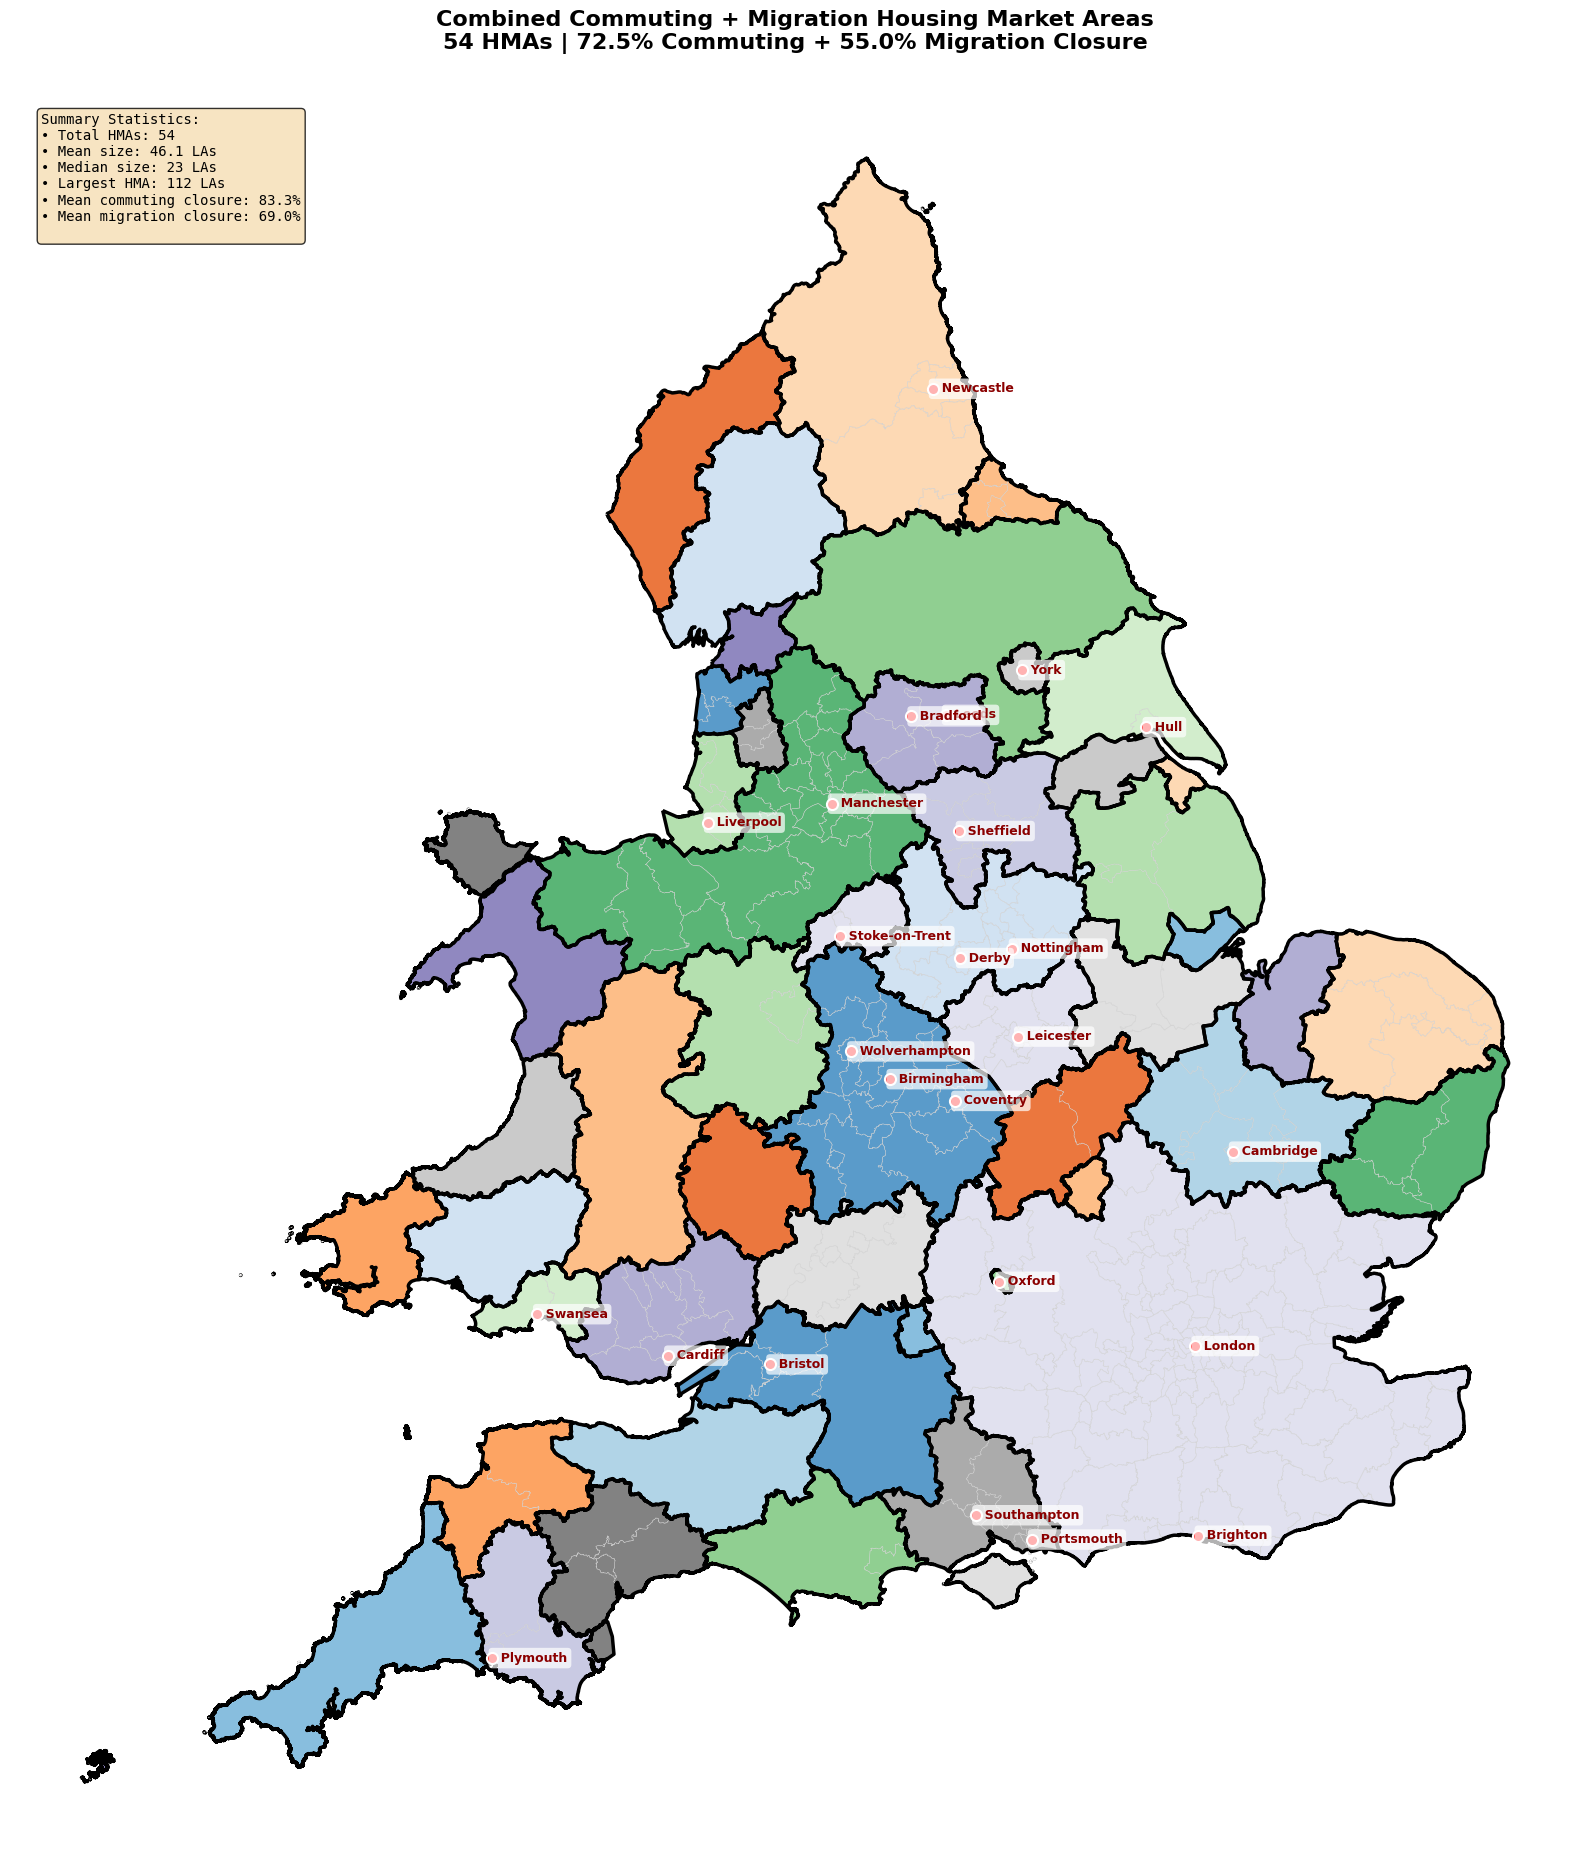

✓ Map created showing 54 housing market areas with 25 major cities


In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np
from shapely.geometry import Point

# Merge HMA data with geographic data
gdf_hma = gdf_la_2023.merge(combined_hma_df, on='LAD23CD', how='left')

# Dissolve geometries by HMA_ID to create single polygons for each region
gdf_hma_dissolved = gdf_hma.dissolve(by='HMA_ID', aggfunc='first')

# Create a colormap with distinct colors
n_hmas = len(gdf_hma_dissolved)
colors = plt.cm.tab20c(np.linspace(0, 1, n_hmas))
np.random.seed(42)
np.random.shuffle(colors)  # Shuffle to avoid adjacent areas having similar colors

# Major cities in England and Wales (lon, lat in WGS84)
major_cities_wgs84 = {
    'London': (-0.1276, 51.5074),
    'Birmingham': (-1.8904, 52.4862),
    'Manchester': (-2.2426, 53.4808),
    'Leeds': (-1.5491, 53.8008),
    'Liverpool': (-2.9916, 53.4084),
    'Sheffield': (-1.4701, 53.3811),
    'Bristol': (-2.5879, 51.4545),
    'Newcastle': (-1.6178, 54.9783),
    'Nottingham': (-1.1581, 52.9548),
    'Southampton': (-1.4044, 50.9097),
    'Cardiff': (-3.1791, 51.4816),
    'Leicester': (-1.1332, 52.6369),
    'Coventry': (-1.5086, 52.4068),
    'Bradford': (-1.7594, 53.7960),
    'Swansea': (-3.9436, 51.6214),
    'Plymouth': (-4.1427, 50.3755),
    'Portsmouth': (-1.0880, 50.8198),
    'Derby': (-1.4746, 52.9225),
    'Wolverhampton': (-2.1234, 52.5864),
    'Stoke-on-Trent': (-2.1894, 53.0027),
    'Hull': (-0.3274, 53.7457),
    'York': (-1.0803, 53.9600),
    'Oxford': (-1.2577, 51.7520),
    'Cambridge': (0.1218, 52.2053),
    'Brighton': (-0.1372, 50.8225)
}

# Convert city coordinates from WGS84 to British National Grid (EPSG:27700)
city_data = []
for city, (lon, lat) in major_cities_wgs84.items():
    city_data.append({'city': city, 'geometry': Point(lon, lat)})

cities_gdf = gpd.GeoDataFrame(city_data, crs='EPSG:4326')
cities_gdf = cities_gdf.to_crs('EPSG:27700')

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(16, 20))

# First layer: Plot individual LAs with soft boundaries
gdf_hma.plot(
    column='HMA_ID',
    ax=ax,
    cmap=ListedColormap(colors),
    edgecolor='lightgray',
    linewidth=0.4,
    legend=False,
    alpha=0.8
)

# Second layer: Plot the dissolved HMA regions with bold borders (no fill)
gdf_hma_dissolved.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=2.5
)

# Add major cities using converted coordinates
for idx, row in cities_gdf.iterrows():
    x, y = row.geometry.x, row.geometry.y
    city_name = row['city']
    
    # Plot city marker
    ax.plot(x, y, 'o', color='red', markersize=8, markeredgecolor='white', 
            markeredgewidth=1.5, zorder=10)
    # Add city label
    ax.text(x, y, f'  {city_name}', fontsize=9, fontweight='bold', 
            verticalalignment='center', color='darkred', zorder=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

# Add title with statistics
title = f'Combined Commuting + Migration Housing Market Areas\n'
title += f'{len(final_hmas)} HMAs | {COMMUTING_THRESHOLD:.1%} Commuting + {MIGRATION_THRESHOLD:.1%} Migration Closure'
ax.set_title(title, fontsize=16, fontweight='bold', pad=20)

# Remove axis
ax.axis('off')

# Add statistics box
stats_text = f"""Summary Statistics:
• Total HMAs: {len(final_hmas)}
• Mean size: {combined_hma_df['HMA_Size'].mean():.1f} LAs
• Median size: {combined_hma_df['HMA_Size'].median():.0f} LAs
• Largest HMA: {combined_hma_df['HMA_Size'].max()} LAs
• Mean commuting closure: {combined_hma_df.groupby('HMA_ID')['Commuting_SC'].first().mean():.1%}
• Mean migration closure: {combined_hma_df.groupby('HMA_ID')['Migration_SC'].first().mean():.1%}
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

print(f"✓ Map created showing {len(final_hmas)} housing market areas with 25 major cities")

In [ ]:
gdf_hma